# Spark Funds Investment Analysis

This notebook analyzes Crunchbase investment data to recommend:

1. A suitable funding type for investments of **USD 5–15 million per round**
2. The leading English-speaking countries for that funding type
3. The most active sectors in those countries

The workflow covers data cleaning, funding-type analysis, country analysis, sector mapping, and visualization.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Make paths work both from the repository root and from notebooks/
ROOT = Path.cwd()
if not (ROOT / "data" / "raw").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data" / "raw"
FIGURE_DIR = ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

COMPANIES_PATH = DATA_DIR / "companies.csv"
ROUNDS_PATH = DATA_DIR / "rounds2.csv"
MAPPING_PATH = DATA_DIR / "mapping.csv"


## 1. Load and clean the data

In [2]:
companies = pd.read_csv(COMPANIES_PATH, encoding="latin1")
rounds2 = pd.read_csv(ROUNDS_PATH, encoding="latin1")
mapping = pd.read_csv(MAPPING_PATH)

print("Companies shape:", companies.shape)
print("Rounds shape:", rounds2.shape)
print("Mapping shape:", mapping.shape)


Companies shape: (66368, 10)
Rounds shape: (114949, 6)
Mapping shape: (688, 10)


In [3]:
def normalize_permalink(series: pd.Series) -> pd.Series:
    """Normalize permalinks so the two source tables join reliably."""
    return (
        series.astype("string")
        .str.encode("latin1", errors="ignore")
        .str.decode("ascii", errors="ignore")
        .str.lower()
        .str.strip()
    )

companies["permalink"] = normalize_permalink(companies["permalink"])
rounds2["company_permalink"] = normalize_permalink(rounds2["company_permalink"])
companies["name"] = (
    companies["name"].astype("string")
    .str.encode("latin1", errors="ignore")
    .str.decode("ascii", errors="ignore")
)

unique_rounds = rounds2["company_permalink"].nunique()
unique_companies = companies["permalink"].nunique()
missing_companies = set(rounds2["company_permalink"].dropna()) - set(companies["permalink"].dropna())

print("Unique companies in rounds2:", unique_rounds)
print("Unique companies in companies:", unique_companies)
print("Unique key in companies: permalink")
print("Companies in rounds2 but not companies:", "Yes" if missing_companies else "No")


Unique companies in rounds2: 66368
Unique companies in companies: 66368
Unique key in companies: permalink
Companies in rounds2 but not companies: No


In [4]:
master_frame = rounds2.merge(
    companies,
    how="left",
    left_on="company_permalink",
    right_on="permalink",
    validate="many_to_one",
)

print("Observations in master_frame:", len(master_frame))
master_frame.head()


Observations in master_frame: 114949


,company_permalink,funding_round_permalink,funding_round_type,funding_round_code,funded_at,raised_amount_usd,permalink,name,homepage_url,category_list,status,country_code,state_code,region,city,founded_at
0,/organization/-fame,/funding-round/9a01d05418af9f794eebff7ace91f638,venture,B,05-01-2015,"10,000,000.00",/organization/-fame,#fame,http://livfame.com,Media,operating,IND,16,Mumbai,Mumbai,NaN
1,/organization/-qounter,/funding-round/22dacff496eb7acb2b901dec1dfe5633,venture,A,14-10-2014,NaN,/organization/-qounter,:Qounter,http://www.qounter.com,Application Platforms|Real Time|Social Network...,operating,USA,DE,DE - Other,Delaware City,04-09-2014
2,/organization/-qounter,/funding-round/b44fbb94153f6cdef13083530bb48030,seed,NaN,01-03-2014,"700,000.00",/organization/-qounter,:Qounter,http://www.qounter.com,Application Platforms|Real Time|Social Network...,operating,USA,DE,DE - Other,Delaware City,04-09-2014
3,/organization/-the-one-of-them-inc-,/funding-round/650b8f704416801069bb178a1418776b,venture,B,30-01-2014,"3,406,878.00",/organization/-the-one-of-them-inc-,"(THE) ONE of THEM,Inc.",http://oneofthem.jp,Apps|Games|Mobile,operating,NaN,NaN,NaN,NaN,NaN
4,/organization/0-6-com,/funding-round/5727accaeaa57461bd22a9bdd945382d,venture,A,19-03-2008,"2,000,000.00",/organization/0-6-com,0-6.com,http://www.0-6.com,Curated Web,operating,CHN,22,Beijing,Beijing,01-01-2007


In [5]:
analysis_frame = master_frame.dropna(
    subset=["raised_amount_usd", "country_code", "category_list"]
).copy()

analysis_frame["raised_amount_usd_m"] = analysis_frame["raised_amount_usd"] / 1_000_000

print("Rows retained for analysis:", len(analysis_frame))


Rows retained for analysis: 88529


## 2. Funding type analysis

In [6]:
funding_types = ["venture", "angel", "seed", "private_equity"]

funding_summary = (
    analysis_frame.loc[analysis_frame["funding_round_type"].isin(funding_types)]
    .groupby("funding_round_type", as_index=False)
    .agg(
        average_investment_usd=("raised_amount_usd", "mean"),
        median_investment_usd=("raised_amount_usd", "median"),
        number_of_rounds=("raised_amount_usd", "count"),
    )
)

funding_summary["average_investment_usd_m"] = funding_summary["average_investment_usd"] / 1_000_000
funding_summary["median_investment_usd_m"] = funding_summary["median_investment_usd"] / 1_000_000
funding_summary.sort_values("average_investment_usd_m")


,funding_round_type,average_investment_usd,median_investment_usd,number_of_rounds,average_investment_usd_m,median_investment_usd_m
2,seed,"747,793.68","300,000.00",21095,0.75,0.30
0,angel,"971,573.89","414,906.00",4400,0.97,0.41
3,venture,"11,724,222.69","5,000,000.00",47809,11.72,5.00
1,private_equity,"73,938,486.28","20,000,000.00",1820,73.94,20.00


In [7]:
eligible_funding_types = funding_summary.loc[
    funding_summary["average_investment_usd_m"].between(5, 15),
    "funding_round_type",
].tolist()

chosen_funding_type = "venture"

print("Funding types with average investment between USD 5M and USD 15M:", eligible_funding_types)
print("Chosen funding type:", chosen_funding_type)


Funding types with average investment between USD 5M and USD 15M: ['venture']
Chosen funding type: venture


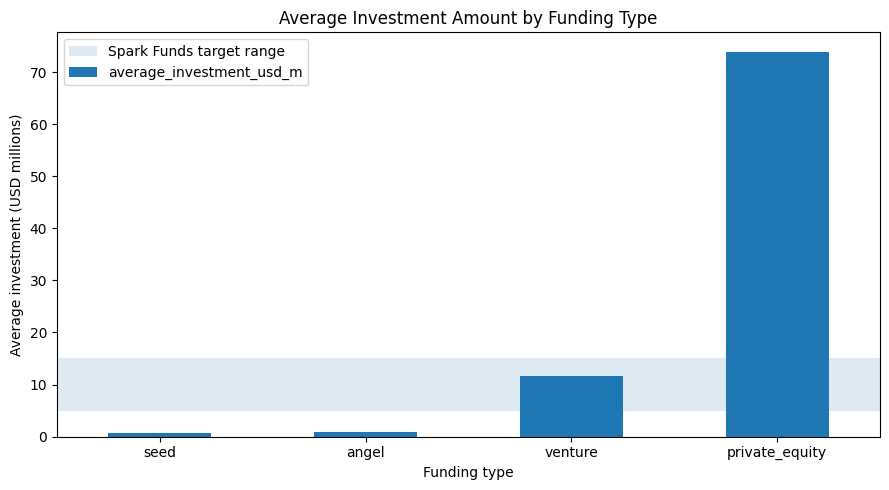

In [8]:
plot_data = funding_summary.set_index("funding_round_type")["average_investment_usd_m"].sort_values()

ax = plot_data.plot(kind="bar", figsize=(9, 5))
ax.axhspan(5, 15, alpha=0.15, label="Spark Funds target range")
ax.set_title("Average Investment Amount by Funding Type")
ax.set_xlabel("Funding type")
ax.set_ylabel("Average investment (USD millions)")
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "01_funding_type_analysis.png", dpi=180)
plt.show()


## 3. Country analysis

In [9]:
venture_frame = analysis_frame.loc[
    analysis_frame["funding_round_type"].eq(chosen_funding_type)
].copy()

top9 = (
    venture_frame.groupby("country_code", as_index=False)["raised_amount_usd"]
    .sum()
    .sort_values("raised_amount_usd", ascending=False)
    .head(9)
)

top9["total_investment_usd_m"] = top9["raised_amount_usd"] / 1_000_000
top9[["country_code", "total_investment_usd_m"]]


,country_code,total_investment_usd_m
94,USA,"420,068.03"
15,CHN,"39,338.92"
29,GBR,"20,072.81"
39,IND,"14,261.51"
12,CAN,"9,482.22"
28,FRA,"7,226.85"
42,ISR,"6,854.35"
21,DEU,"6,306.92"
45,JPN,"3,167.65"


In [10]:
# English is an official language in these countries in the assignment's top-nine set.
english_speaking_codes = {"USA", "GBR", "IND", "CAN"}

top_english_countries = (
    top9.loc[top9["country_code"].isin(english_speaking_codes), "country_code"]
    .head(3)
    .tolist()
)

print("Top three English-speaking countries:", top_english_countries)


Top three English-speaking countries: ['USA', 'GBR', 'IND']


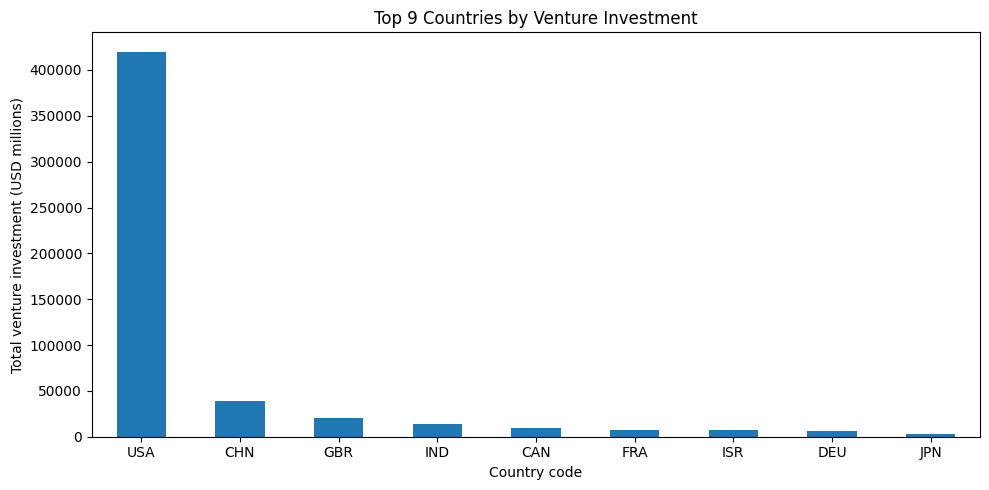

In [11]:
ax = top9.set_index("country_code")["total_investment_usd_m"].plot(
    kind="bar", figsize=(10, 5)
)
ax.set_title("Top 9 Countries by Venture Investment")
ax.set_xlabel("Country code")
ax.set_ylabel("Total venture investment (USD millions)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "02_top9_countries.png", dpi=180)
plt.show()


## 4. Sector mapping

In [12]:
venture_frame["primary_sector"] = (
    venture_frame["category_list"].str.split("|").str[0].str.strip()
)

# The source mapping file contains strings where 'na' was replaced with '0'.
mapping_clean = mapping.copy()
mapping_clean["category_list"] = mapping_clean["category_list"].replace(
    {"0": "na", "2.na": "2.0"}, regex=True
)

sector_columns = [column for column in mapping_clean.columns if column != "category_list"]

mapping_long = (
    mapping_clean.melt(
        id_vars="category_list",
        value_vars=sector_columns,
        var_name="main_sector",
        value_name="is_mapped",
    )
    .loc[lambda df: df["is_mapped"].eq(1), ["category_list", "main_sector"]]
    .rename(columns={"category_list": "primary_sector"})
)

venture_sector_frame = venture_frame.merge(
    mapping_long,
    how="left",
    on="primary_sector",
    validate="many_to_one",
)

unmapped = sorted(
    venture_sector_frame.loc[
        venture_sector_frame["main_sector"].isna(), "primary_sector"
    ].dropna().unique()
)
print("Unmapped primary sectors:", unmapped[:20])
print("Number of unmapped primary sectors:", len(unmapped))

venture_sector_frame = venture_sector_frame.dropna(subset=["main_sector"]).copy()


Unmapped primary sectors: ['Adaptive Equipment', 'Biotechnology and Semiconductor', 'English-Speaking', 'Enterprise 2.0', 'Enterprise Hardware', 'GreenTech', 'Nanotechnology', 'Natural Gas Uses', 'Natural Language Processing', 'Natural Resources', 'Navigation', 'Product Search', 'Racing', 'Rapidly Expanding', 'Retirement', 'Specialty Retail']
Number of unmapped primary sectors: 16


## 5. Sector analysis for USD 5–15 million venture rounds

In [13]:
COUNTRIES = ["USA", "GBR", "IND"]

eligible_rounds = venture_sector_frame.loc[
    venture_sector_frame["country_code"].isin(COUNTRIES)
    & venture_sector_frame["raised_amount_usd_m"].between(5, 15)
].copy()

def build_country_frame(country_code: str) -> pd.DataFrame:
    country = eligible_rounds.loc[eligible_rounds["country_code"].eq(country_code)].copy()
    sector_stats = (
        country.groupby("main_sector")["raised_amount_usd"]
        .agg(total_amount_usd="sum", total_investment_count="count")
        .reset_index()
    )
    return country.merge(sector_stats, on="main_sector", how="left")

D1 = build_country_frame("USA")
D2 = build_country_frame("GBR")
D3 = build_country_frame("IND")

print("D1 (USA):", D1.shape)
print("D2 (GBR):", D2.shape)
print("D3 (IND):", D3.shape)


D1 (USA): (12012, 21)
D2 (GBR): (619, 21)
D3 (IND): (328, 21)


In [14]:
def sector_ranking(country_df: pd.DataFrame) -> pd.DataFrame:
    return (
        country_df.groupby("main_sector", as_index=False)
        .agg(
            investment_count=("raised_amount_usd", "count"),
            total_investment_usd=("raised_amount_usd", "sum"),
        )
        .sort_values(["investment_count", "total_investment_usd"], ascending=False)
    )

rankings = {
    "USA": sector_ranking(D1),
    "GBR": sector_ranking(D2),
    "IND": sector_ranking(D3),
}

summary_rows = []
for country_code, frame in zip(COUNTRIES, [D1, D2, D3]):
    ranking = rankings[country_code].reset_index(drop=True)
    row = {
        "country": country_code,
        "total_investments": len(frame),
        "total_amount_usd": frame["raised_amount_usd"].sum(),
    }
    for i in range(3):
        row[f"sector_{i+1}"] = ranking.loc[i, "main_sector"]
        row[f"sector_{i+1}_count"] = int(ranking.loc[i, "investment_count"])
    summary_rows.append(row)

sector_summary = pd.DataFrame(summary_rows)
sector_summary


,country,total_investments,total_amount_usd,sector_1,sector_1_count,sector_2,sector_2_count,sector_3,sector_3_count
0,USA,12012,"107,318,294,664.00",Others,2950,"Social, Finance, Analytics, Advertising",2714,Cleantech / Semiconductors,2300
1,GBR,619,"5,365,228,300.00",Others,147,"Social, Finance, Analytics, Advertising",133,Cleantech / Semiconductors,128
2,IND,328,"2,949,543,602.00",Others,110,"Social, Finance, Analytics, Advertising",60,"News, Search and Messaging",52


In [15]:
def highest_funded_company(country_df: pd.DataFrame, sector: str) -> pd.Series:
    company_totals = (
        country_df.loc[country_df["main_sector"].eq(sector)]
        .groupby(["company_permalink", "name"], dropna=False)["raised_amount_usd"]
        .sum()
        .sort_values(ascending=False)
    )
    return company_totals.head(1)

for country_code, frame in zip(COUNTRIES, [D1, D2, D3]):
    ranking = rankings[country_code].reset_index(drop=True)
    print(f"\n{country_code}")
    for rank in [0, 1]:
        sector = ranking.loc[rank, "main_sector"]
        print(f"{rank + 1}. {sector}")
        print(highest_funded_company(frame, sector))



USA
1. Others
company_permalink          name       
/organization/virtustream  Virtustream   64,300,000.00
Name: raised_amount_usd, dtype: float64
2. Social, Finance, Analytics, Advertising
company_permalink          name                           
/organization/shotspotter  SST Inc. (Formerly ShotSpotter)   67,933,006.00
Name: raised_amount_usd, dtype: float64

GBR
1. Others
company_permalink             name          
/organization/electric-cloud  Electric Cloud   37,000,000.00
Name: raised_amount_usd, dtype: float64
2. Social, Finance, Analytics, Advertising
company_permalink                    name                 
/organization/celltick-technologies  Celltick Technologies   37,500,000.00
Name: raised_amount_usd, dtype: float64

IND
1. Others
company_permalink           name        
/organization/firstcry-com  FirstCry.com   39,000,000.00
Name: raised_amount_usd, dtype: float64
2. Social, Finance, Analytics, Advertising
company_permalink              name           
/organization

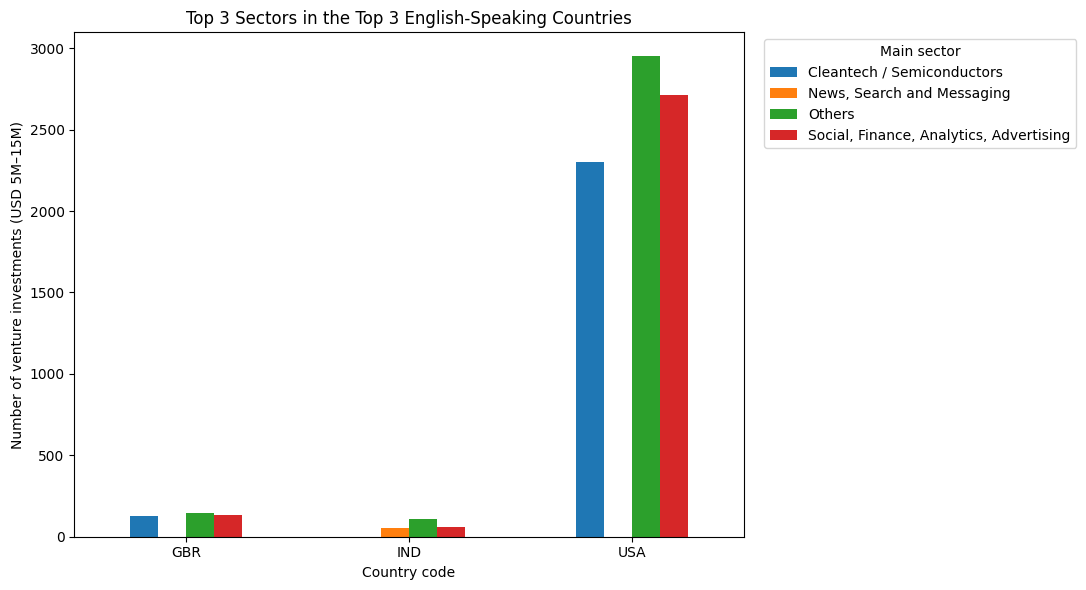

In [16]:
top3_plot_rows = []
for country_code in COUNTRIES:
    ranking = rankings[country_code].head(3)
    for _, row in ranking.iterrows():
        top3_plot_rows.append(
            {
                "country_code": country_code,
                "main_sector": row["main_sector"],
                "investment_count": row["investment_count"],
            }
        )

top3_plot = pd.DataFrame(top3_plot_rows)
plot_pivot = top3_plot.pivot(
    index="country_code", columns="main_sector", values="investment_count"
).fillna(0)

ax = plot_pivot.plot(kind="bar", figsize=(11, 6))
ax.set_title("Top 3 Sectors in the Top 3 English-Speaking Countries")
ax.set_xlabel("Country code")
ax.set_ylabel("Number of venture investments (USD 5M–15M)")
plt.xticks(rotation=0)
plt.legend(title="Main sector", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "03_top_sectors_by_country.png", dpi=180)
plt.show()


## 6. Recommendation

The analysis supports the following recommendation:

- **Funding type:** Venture
- **Priority countries:** United States, United Kingdom, and India
- **Priority sectors:** Focus on the highest-count sectors within each country, particularly **Others**, **Social, Finance, Analytics, Advertising**, and **News, Search and Messaging**, while considering country-specific rankings.

The recommendation follows Spark Funds' stated strategy of investing where investment activity is already concentrated.
